In [7]:
%pip install pydicom

  Using cached pydicom-3.0.2-py3-none-any.whl.metadata (9.4 kB)
Using cached pydicom-3.0.2-py3-none-any.whl (2.4 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
import pydicom
import matplotlib.pyplot as plt
import glob
folder = f'C:/medicalAI/Pycham/sample/pneumothorax'
files = sorted(glob.glob(folder + r'/**/*.dcm', recursive=True))
print(f'DICOM file{len(files)}')

DICOM file427


In [11]:
dcm = pydicom.dcmread(files[0])
print(dcm)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 200
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.5797.1517875190.762694
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.5797.1517875190.762694
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                    

In [15]:
print("Age:", dcm.PatientAge)
print("Sex:", dcm.PatientSex)
print("Modality:", dcm.Modality, "(Computed Radiography)")
print("Bodypart:", dcm.BodyPartExamined)
print("position:", dcm.ViewPosition, "(PA)")
print("Pixel:", dcm.PixelSpacing, "mm")
print("size:", dcm.Rows, 'x', dcm.Columns)

Age: 81
Sex: M
Modality: CR (Computed Radiography)
Bodypart: CHEST
position: PA (PA)
Pixel: [0.14300000000000002, 0.14300000000000002] mm
size: 1024 x 1024


In [20]:
#Pixel sapcing is real mm of real pixel -> if saved it as png, information gone.
#do not know accurate size of illness
interval = float(dcm.PixelSpacing[0])
print(f'one Pixel = {interval:.3f}mm')
print(f'whole photo = {dcm.Rows *interval / 10:.1f}cm')
print(f'x{dcm.Columns * interval / 10:.1f}cm')
for p in (10, 50, 100, 300):
    print(f'{p:3d}length of pixel = real{p* interval:5.1f}mm')

one Pixel = 0.143mm
whole photo = 14.6cm
x14.6cm
 10length of pixel = real  1.4mm
 50length of pixel = real  7.2mm
100length of pixel = real 14.3mm
300length of pixel = real 42.9mm


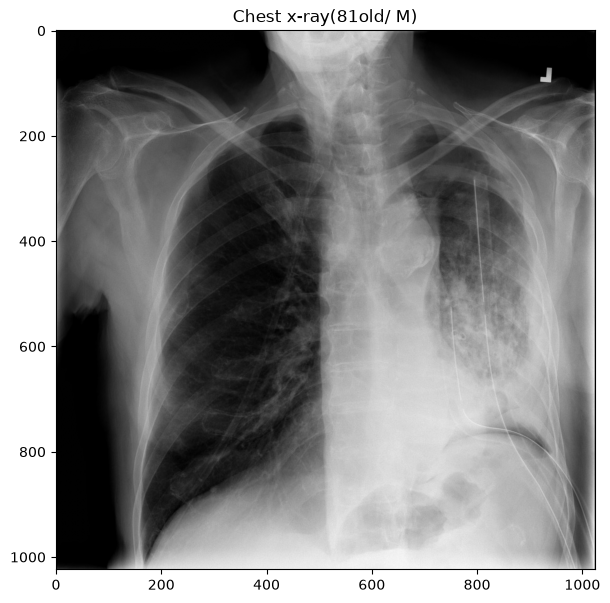

In [23]:
img = dcm.pixel_array
plt.figure(figsize=(7, 7))
plt.imshow(img, cmap='gray')
plt.title(f'Chest x-ray({dcm.PatientAge}old/ {dcm.PatientSex})')
plt.show()

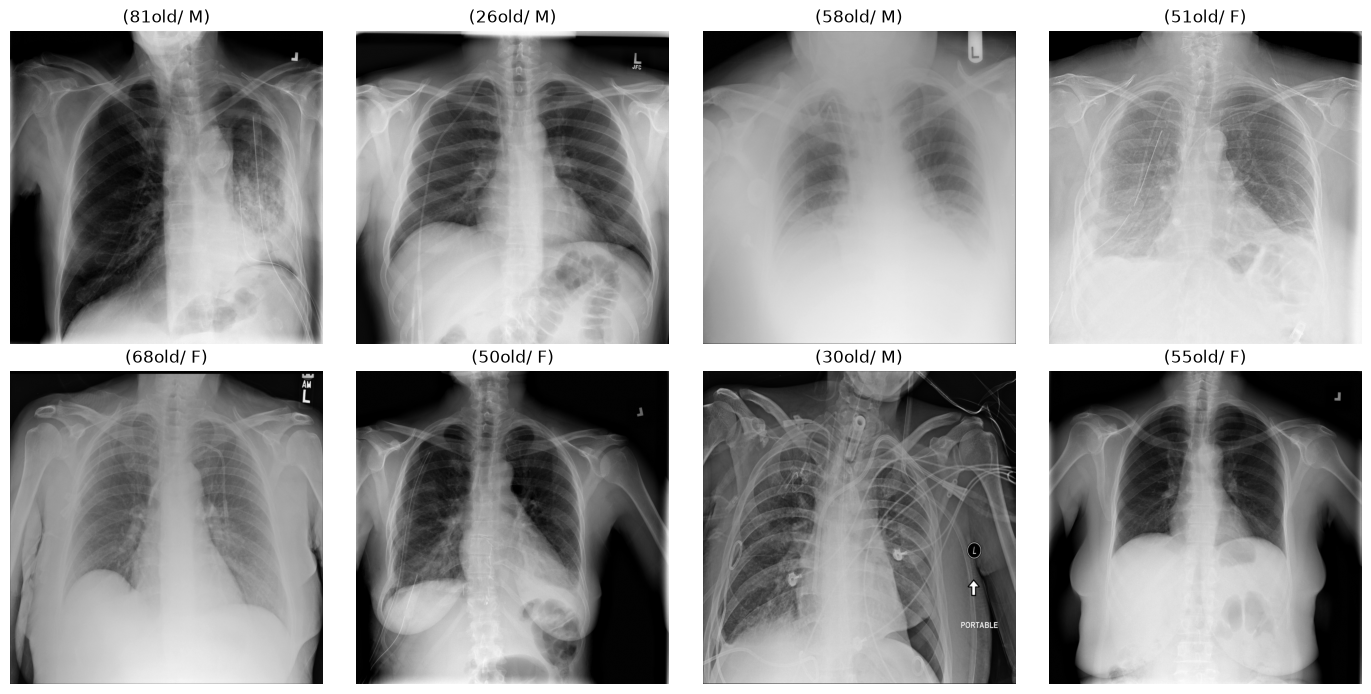

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, file in zip(axes.flatten(), files[:8]):
    d=pydicom.dcmread(file)
    ax.imshow(d.pixel_array, cmap='gray')
    ax.set_title(f'({d.PatientAge}old/ {d.PatientSex})')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [28]:
#Edit information
print('before edit')
print(f'name:{dcm.PatientName}')
dcm.PatientName = 'ID0001'
print('after edit')
print(f'name:{dcm.PatientName}')
dcm.save_as('id0001.dcm')
print('save complete')

before edit
name:d6a76eb1-d814-46b1-a375-fcc796d2b0b0
after edit
name:ID0001
save complete


In [43]:

ages =[]
for f in files:
    dcm = pydicom.dcmread(f)
    if 'PatientAge' in dcm and dcm.PatientAge:
        age = int(''.join(filter(str.isdigit, dcm.PatientAge)))
        ages.append(age)
#mean
if ages:
    mean_age = sum(ages)/len(ages)
    print(f'Age_mean:{mean_age:.1f} old')
else:
    print('can not find information')



Age_mean:46.9 old


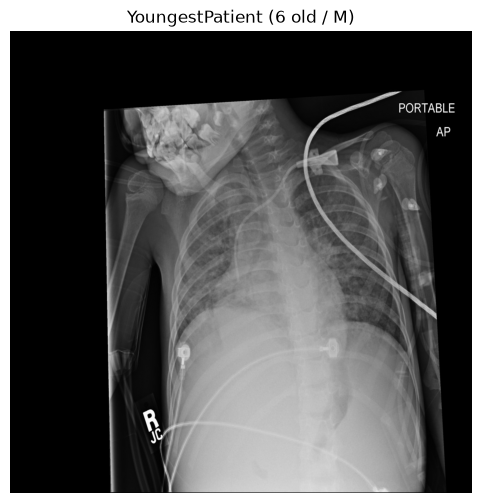

The youngest age: 6old


In [44]:
youngest_file = None
min_age = float('inf')

for file in files:
    d = pydicom.dcmread(file)
    if 'PatientAge' in d and d.PatientAge:
        age = int(''.join(filter(str.isdigit, d.PatientAge)))
        if age< min_age:
            min_age = age
            youngest_file = file
if youngest_file:
    d_youngest = pydicom.dcmread(youngest_file)

    plt.figure(figsize=(6, 6))
    plt.imshow(d_youngest.pixel_array, cmap='gray')
    plt.title(f'YoungestPatient ({d_youngest.PatientAge} old / {d_youngest.PatientSex})')
    plt.axis('off')
    plt.show()

    print(f'The youngest age: {min_age}old')
    
    